# Importación de librerías

In [1]:
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import filters_and_features as ff
import data_processor as dp
import numpy as np
from sklearn.decomposition import PCA

# Importación de datos

In [2]:
df = dp.lectura(mode=1) # Leyendo 9 primeros individuos
df_val = dp.lectura(mode=2) # Leyendo 10mo individuo

Se crea el dataframe df_block

In [3]:
df_block = dp.create_df_block(df)
df_block_val = dp.create_df_block(df_val)

In [4]:
del df
del df_val

Se limpia y visualiza el contenido

In [5]:
dp.balance(df_block)
dp.balance(df_block_val)
print(df_block['stimulus'].value_counts())
print(df_block_val['stimulus'].value_counts())

stimulus
1     408
0     408
3     408
4     408
6     408
9     408
10    408
11    408
Name: count, dtype: int64
stimulus
1     48
3     48
0     48
4     48
6     48
9     48
10    48
11    48
Name: count, dtype: int64


# Filtro

In [6]:
df_block_filtered = dp.filter(df_block)
df_block_filtered_val = dp.filter(df_block_val)

Procesando: 100%|██████████| 3/3 [00:13<00:00,  4.34s/it]


In [7]:
del df_block
del df_block_val

# Extracción de características

In [8]:
df_block_features = dp.get_carac(df_block_filtered)
df_block_features_val = dp.get_carac(df_block_filtered_val)

Extrayendo Características: 100%|██████████| 384/384 [00:56<00:00,  6.76it/s]


In [9]:
del df_block_filtered
del df_block_filtered_val

In [10]:
df_block_features.describe()

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,rms_2,iemg_2,mav_2,wl_2,...,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus,Stimulus
count,3264.000000,3264.000000,3264.000000,3264.000000,3.264000e+03,3.264000e+03,3264.000000,3264.000000,3264.000000,3264.000000,...,3264.000000,3264.000000,3264.000000,3264.000000,3264.000000,3264.000000,3264.000000,3264.000000,3264.0,3264.000000
mean,0.000024,0.135836,0.000014,0.033239,7.027871e-06,5.807712e-09,0.000061,0.293211,0.000031,0.044233,...,0.000991,235.236463,37.578738,872.679841,330.155331,43.068363,15.110501,0.297278,0.0,5.500000
std,0.000026,0.128349,0.000013,0.023985,6.209986e-06,3.772203e-08,0.000139,0.640688,0.000069,0.071158,...,0.000076,28.962662,5.289352,185.611001,105.854004,23.322655,10.199919,0.091040,0.0,3.905723
min,0.000003,0.021010,0.000003,0.004989,9.991979e-07,5.281826e-11,0.000003,0.013700,0.000002,0.003050,...,0.000028,91.869132,14.000000,92.000000,69.000000,0.193630,6.508538,0.170700,0.0,0.000000
25%,0.000014,0.081767,0.000009,0.020697,4.315863e-06,9.512228e-10,0.000013,0.073505,0.000008,0.017144,...,0.000968,206.751299,36.000000,718.000000,226.000000,30.014316,10.919878,0.257171,0.0,2.500000
50%,0.000019,0.111289,0.000012,0.028619,5.781790e-06,1.665798e-09,0.000018,0.104273,0.000011,0.024010,...,0.000995,252.114134,39.000000,860.500000,375.000000,40.003942,12.219369,0.270859,0.0,5.000000
75%,0.000025,0.152668,0.000016,0.039298,7.841545e-06,3.055492e-09,0.000027,0.156107,0.000016,0.035028,...,0.001022,255.705930,41.000000,1042.000000,414.000000,59.931147,15.377464,0.307481,0.0,9.250000
max,0.000578,2.966872,0.000293,0.446697,1.111817e-04,1.691747e-06,0.000966,5.355006,0.000581,0.597110,...,0.001408,264.506318,54.000000,1730.000000,685.000000,148.944539,245.573746,1.969492,0.0,11.000000


In [11]:
df_block_features_val.describe()

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,rms_2,iemg_2,mav_2,wl_2,...,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus,Stimulus
count,384.000000,384.000000,384.000000,384.000000,384.000000,3.840000e+02,384.000000,384.000000,384.000000,384.000000,...,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.0,384.00000
mean,0.000020,0.129160,0.000014,0.032886,0.000007,2.357532e-09,0.000034,0.208759,0.000022,0.052722,...,0.000983,255.794424,40.437500,1024.239583,393.979167,48.100276,11.438918,0.262345,0.0,5.50000
std,0.000009,0.055020,0.000006,0.015773,0.000002,2.415242e-09,0.000017,0.066264,0.000007,0.017648,...,0.000031,2.909339,1.388596,103.103891,44.287036,21.071929,1.272806,0.013472,0.0,3.91022
min,0.000007,0.036229,0.000005,0.008748,0.000002,2.189966e-10,0.000017,0.077546,0.000009,0.018305,...,0.000816,246.180577,36.000000,692.000000,259.000000,0.197044,8.547231,0.229085,0.0,0.00000
25%,0.000015,0.093095,0.000010,0.022358,0.000005,9.943350e-10,0.000027,0.168759,0.000018,0.041385,...,0.000968,253.948577,40.000000,992.000000,378.000000,33.270064,10.536642,0.253283,0.0,2.50000
50%,0.000019,0.119254,0.000013,0.029627,0.000007,1.656022e-09,0.000033,0.202408,0.000022,0.049796,...,0.000986,255.756111,40.000000,1040.000000,402.000000,42.946907,11.348504,0.261304,0.0,5.00000
75%,0.000024,0.151803,0.000016,0.038523,0.000008,2.744106e-09,0.000038,0.241356,0.000025,0.061283,...,0.001004,257.605350,41.000000,1098.000000,421.000000,65.880141,12.086874,0.270011,0.0,9.25000
max,0.000076,0.368333,0.000036,0.106128,0.000017,2.244927e-08,0.000301,0.752266,0.000074,0.117802,...,0.001050,266.462495,44.000000,1190.000000,503.000000,107.309333,18.693437,0.325780,0.0,11.00000


# Normalización

In [12]:
scaler, df_block_normalized = dp.normalize(df_block_features)
df_block_normalized_val = dp.normalize(df_block_features_val, scaler)

In [13]:
del df_block_features
del df_block_features_val

In [14]:
df_block_normalized.describe()

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,rms_2,iemg_2,mav_2,wl_2,...,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus,Stimulus
count,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,...,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3264.0,3264.000000
mean,8.707632e-18,1.219068e-16,-6.095342e-17,6.095342e-17,-5.224579e-17,3.483053e-17,-6.966105e-17,5.224579e-17,5.224579e-17,3.483053e-17,...,-1.062331e-15,4.527968e-16,6.966105e-17,2.089832e-16,6.966105e-17,-2.002755e-16,1.131992e-16,-2.089832e-16,0.0,5.500000
std,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,...,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,0.0,3.905723
min,-7.884288e-01,-8.947756e-01,-8.720450e-01,-1.178008e+00,-9.709518e-01,-1.525839e-01,-4.232081e-01,-4.363346e-01,-4.295537e-01,-5.788420e-01,...,-1.270215e+01,-4.950833e+00,-4.458457e+00,-4.206644e+00,-2.467506e+00,-1.838612e+00,-8.434656e-01,-1.390586e+00,0.0,0.000000
25%,-3.655992e-01,-4.213294e-01,-4.146898e-01,-5.230136e-01,-4.367842e-01,-1.287638e-01,-3.500839e-01,-3.429750e-01,-3.403024e-01,-3.807423e-01,...,-3.097920e-01,-9.836640e-01,-2.985204e-01,-8.334826e-01,-9.841034e-01,-5.598011e-01,-4.109116e-01,-4.406210e-01,0.0,2.500000
50%,-1.897357e-01,-1.912788e-01,-1.923698e-01,-1.926492e-01,-2.006883e-01,-1.098178e-01,-3.149765e-01,-2.949439e-01,-2.960027e-01,-2.842401e-01,...,4.846617e-02,5.828282e-01,2.687437e-01,-6.563031e-02,4.237113e-01,-1.314126e-01,-2.834900e-01,-2.902428e-01,0.0,5.000000
75%,5.903095e-02,1.311636e-01,1.137400e-01,2.526708e-01,1.310469e-01,-7.297173e-02,-2.504890e-01,-2.140281e-01,-2.174649e-01,-1.293802e-01,...,4.089662e-01,7.068619e-01,6.469197e-01,9.123710e-01,7.921998e-01,7.231324e-01,2.617711e-02,1.120791e-01,0.0,9.250000
max,2.147580e+01,2.206072e+01,2.076002e+01,1.724104e+01,1.677457e+01,4.470062e+01,6.512137e+00,7.901774e+00,8.009224e+00,7.770912e+00,...,5.502714e+00,1.010761e+00,3.105064e+00,4.619616e+00,3.352722e+00,4.540323e+00,2.259808e+01,1.837081e+01,0.0,11.000000


In [15]:
df_block_normalized_val.describe()

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,rms_2,iemg_2,mav_2,wl_2,...,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus,Stimulus
count,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,...,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.0,384.00000
mean,-0.125258,-0.052019,-0.051186,-0.014712,0.013524,-0.091477,-0.194818,-0.131834,-0.132853,0.119319,...,-0.101874,0.709918,0.540558,0.816670,0.603034,0.215785,-0.360017,-0.383777,0.0,5.50000
std,0.346111,0.428744,0.410498,0.657719,0.400617,0.064037,0.125019,0.103442,0.100614,0.248052,...,0.415188,0.100467,0.262567,0.555569,0.418443,0.903635,0.124805,0.148003,0.0,3.91022
min,-0.635055,-0.776184,-0.718579,-1.021252,-0.763403,-0.148178,-0.317357,-0.336667,-0.317761,-0.364421,...,-2.314179,0.377928,-0.298520,-0.973582,-0.672306,-1.838465,-0.643562,-0.749172,0.0,0.00000
25%,-0.345099,-0.333053,-0.316414,-0.453726,-0.268873,-0.127621,-0.244517,-0.194277,-0.195415,-0.040023,...,-0.311541,0.646176,0.457832,0.642949,0.452057,-0.420184,-0.448490,-0.483332,0.0,2.50000
50%,-0.189945,-0.129213,-0.119223,-0.150605,-0.050453,-0.110077,-0.206351,-0.141749,-0.141708,0.078198,...,-0.062304,0.708595,0.457832,0.901594,0.678819,-0.005208,-0.368883,-0.395208,0.0,5.00000
75%,0.010560,0.124428,0.109890,0.220349,0.215617,-0.081228,-0.166737,-0.080948,-0.089160,0.239652,...,0.166827,0.772454,0.646920,1.214124,0.858339,0.978245,-0.296482,-0.299558,0.0,9.25000
max,2.024472,1.811724,1.653161,3.039447,1.554956,0.441230,1.724087,0.716613,0.625452,1.034041,...,0.780154,1.078313,1.214184,1.709860,1.633109,2.754867,0.351325,0.313120,0.0,11.00000


# Creación de dataframes de entrenamiento y testeo

In [16]:
y = df_block_normalized.iloc[:, -1]
X = df_block_normalized.iloc[:, :-1]
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    random_state=100,
                                                    test_size=0.30,
                                                    shuffle=True)

In [17]:
y_val = df_block_normalized_val.iloc[:, -1]
X_val = df_block_normalized_val.iloc[:, :-1]

In [18]:
del df_block_normalized
del df_block_normalized_val

In [19]:
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)

(2284, 212) (2284,)
(384, 212) (384,)


# Entrenamiento y testeo del modelo

Importamos librerías

In [20]:
# Random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Rotation forest
from sktime.classification.sklearn import RotationForest
from sktime.datasets import load_unit_test
from sktime.datatypes._panel._convert import from_nested_to_3d_numpy

# Artificial Neural Networks (ANN)
import setuptools.dist
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

In [21]:
# Visualization libraries

import seaborn as sns

Random forest

In [22]:
rf = RandomForestClassifier(
    max_depth=20,             # Profundidad máxima de los árboles
    criterion='entropy',      # Criterio de medida para la calidad de la división ('entropy' o 'gini')
    min_samples_split=4,      # Número mínimo de muestras requeridas para dividir un nodo
    random_state=99,          # Para reproducibilidad del modelo
    n_estimators=3000,        # Número de árboles en el bosque
    verbose=0,                # Imprimir información durante el entrenamiento
    oob_score=True,           # Calcular la precisión del modelo fuera de la bolsa (OOB)
    n_jobs=-1                 # Usar todos los procesadores disponibles para acelerar el entrenamiento
)
rf.fit(X_train, y_train)
y_pred_RanF = rf.predict(X_test)
y_pred_RanF_val = rf.predict(X_val)

Rotation forest

In [23]:
clf = RotationForest(n_estimators=300)
clf.fit(X_train, y_train)
y_pred_RotF = clf.predict(X_test)
y_pred_RotF_val = clf.predict(X_val)

Artificial Neural Networks (ANN)

In [24]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # Transforma las etiquetas a valores consecutivos (0 a 7)
y_test_enc = le.transform(y_test)

# Asegurarse de que el número de clases sea correcto
num_classes = len(np.unique(y_train_enc))
print("Número de clases detectadas en y_train_b:", num_classes)  # Esto debería ser 8

# Convertir a formato categórico
y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=num_classes)

# Definir y entrenar la red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  # La capa de salida ahora usa 8 neuronas, una por clase
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train_cat, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Predicción y decodificación
y_pred_probs = model.predict(X_test)
y_pred_ann_e = np.argmax(y_pred_probs, axis=1)
y_pred_ann = le.inverse_transform(y_pred_ann_e)  # Convertir a las etiquetas originales

# Predicción y decodificación
y_pred_probs_val = model.predict(X_val)
y_pred_ann_e_val = np.argmax(y_pred_probs_val, axis=1)
y_pred_ann_val = le.inverse_transform(y_pred_ann_e_val)  # Convertir a las etiquetas originales

Número de clases detectadas en y_train_b: 8


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


# Resultados

Random forest

Test data

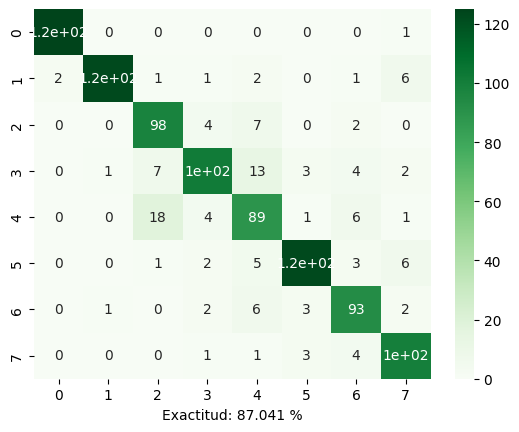

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       126
           1       0.98      0.90      0.94       136
           3       0.78      0.88      0.83       111
           4       0.88      0.77      0.82       132
           6       0.72      0.75      0.74       119
           9       0.92      0.88      0.90       140
          10       0.82      0.87      0.85       107
          11       0.85      0.92      0.88       109

    accuracy                           0.87       980
   macro avg       0.87      0.87      0.87       980
weighted avg       0.87      0.87      0.87       980



In [25]:
sns.heatmap(confusion_matrix(y_pred_RanF, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RanF, y_test))

Validation data

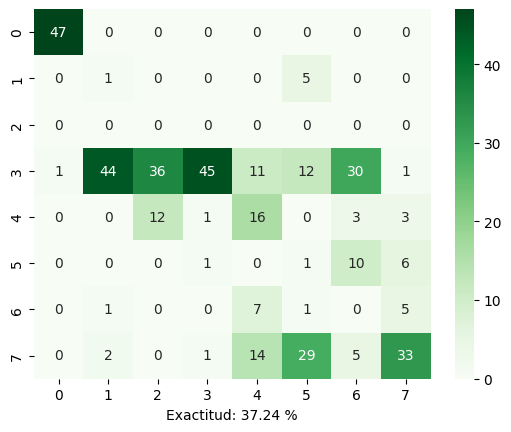

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        47
           1       0.02      0.17      0.04         6
           3       0.00      0.00      0.00         0
           4       0.94      0.25      0.39       180
           6       0.33      0.46      0.39        35
           9       0.02      0.06      0.03        18
          10       0.00      0.00      0.00        14
          11       0.69      0.39      0.50        84

    accuracy                           0.37       384
   macro avg       0.37      0.29      0.29       384
weighted avg       0.74      0.37      0.45       384



c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [26]:
sns.heatmap(confusion_matrix(y_pred_RanF_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RanF_val, y_val))

Rotation forest

Test data

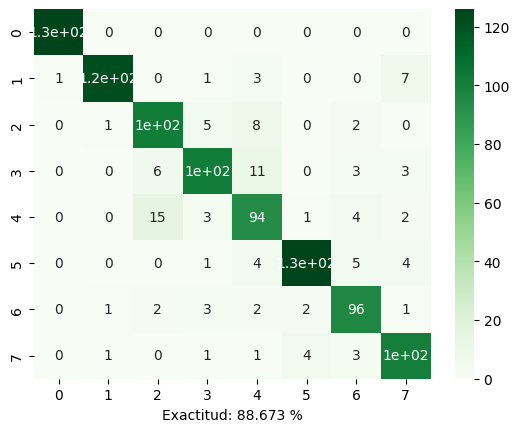

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       126
           1       0.98      0.91      0.94       134
           3       0.82      0.86      0.84       118
           4       0.88      0.82      0.85       125
           6       0.76      0.79      0.78       119
           9       0.95      0.90      0.92       140
          10       0.85      0.90      0.87       107
          11       0.86      0.91      0.88       111

    accuracy                           0.89       980
   macro avg       0.89      0.89      0.88       980
weighted avg       0.89      0.89      0.89       980



In [27]:
sns.heatmap(confusion_matrix(y_pred_RotF, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RotF, y_test))

Validation data

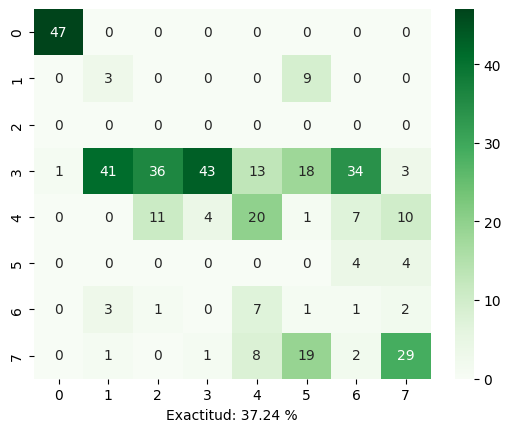

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        47
           1       0.06      0.25      0.10        12
           3       0.00      0.00      0.00         0
           4       0.90      0.23      0.36       189
           6       0.42      0.38      0.40        53
           9       0.00      0.00      0.00         8
          10       0.02      0.07      0.03        15
          11       0.60      0.48      0.54        60

    accuracy                           0.37       384
   macro avg       0.37      0.30      0.30       384
weighted avg       0.72      0.37      0.44       384



c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [28]:
sns.heatmap(confusion_matrix(y_pred_RotF_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RotF_val, y_val))

Artificial Neural Networks (ANN)

Test data

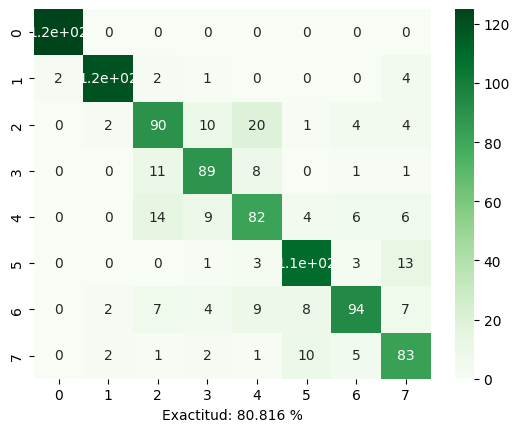

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       125
           1       0.95      0.93      0.94       128
           3       0.72      0.69      0.70       131
           4       0.77      0.81      0.79       110
           6       0.67      0.68      0.67       121
           9       0.83      0.85      0.84       130
          10       0.83      0.72      0.77       131
          11       0.70      0.80      0.75       104

    accuracy                           0.81       980
   macro avg       0.81      0.81      0.81       980
weighted avg       0.81      0.81      0.81       980



In [29]:
sns.heatmap(confusion_matrix(y_pred_ann, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann, y_test),3)} %')
plt.show()
print(classification_report(y_pred_ann, y_test))

Validation data

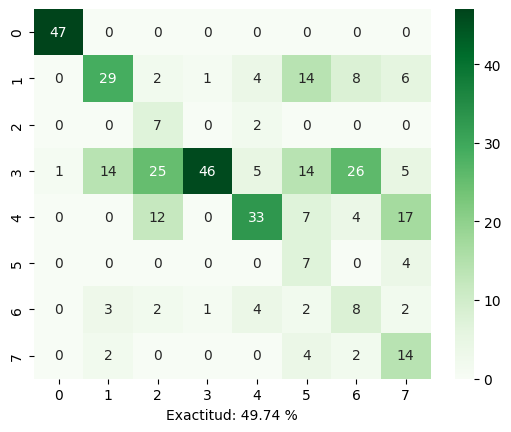

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        47
           1       0.60      0.45      0.52        64
           3       0.15      0.78      0.25         9
           4       0.96      0.34      0.50       136
           6       0.69      0.45      0.55        73
           9       0.15      0.64      0.24        11
          10       0.17      0.36      0.23        22
          11       0.29      0.64      0.40        22

    accuracy                           0.50       384
   macro avg       0.50      0.58      0.46       384
weighted avg       0.72      0.50      0.54       384



In [30]:
sns.heatmap(confusion_matrix(y_pred_ann_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_ann_val, y_val))

# Con PCA

In [31]:
pca = PCA(n_components=80)

X_pca = pca.fit_transform(X)

X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y,
                                                    random_state=100,
                                                    test_size=0.30,
                                                    shuffle=True)

X_pca_val = pca.transform(X_val)

In [32]:
print('Sin PCA')
print(X.shape)
print(X_pca.shape)
print('Con PCA')
print(X_val.shape)
print(X_pca_val.shape)

Sin PCA
(3264, 212)
(3264, 80)
Con PCA
(384, 212)
(384, 80)


Random forest

In [33]:
rf_pca = RandomForestClassifier(
    max_depth=20,             # Profundidad máxima de los árboles
    criterion='entropy',      # Criterio de medida para la calidad de la división ('entropy' o 'gini')
    min_samples_split=4,      # Número mínimo de muestras requeridas para dividir un nodo
    random_state=99,          # Para reproducibilidad del modelo
    n_estimators=3000,        # Número de árboles en el bosque
    verbose=0,                # Imprimir información durante el entrenamiento
    oob_score=True,           # Calcular la precisión del modelo fuera de la bolsa (OOB)
    n_jobs=-1                 # Usar todos los procesadores disponibles para acelerar el entrenamiento
)
rf_pca.fit(X_train_pca, y_train)
y_pred_RanF_pca = rf_pca.predict(X_test_pca)
y_pred_RanF_pca_val = rf_pca.predict(X_pca_val)

Rotation forest

In [34]:
clf_pca = RotationForest(n_estimators=300)
clf_pca.fit(X_train_pca, y_train)
y_pred_RotF_pca = clf_pca.predict(X_test_pca)
y_pred_RotF_pca_val = clf_pca.predict(X_pca_val)

Artificial Neural Networks (ANN)

In [35]:
le_pca = LabelEncoder()
y_train_enc = le_pca.fit_transform(y_train)  # Transforma las etiquetas a valores consecutivos (0 a 7)
y_test_enc = le_pca.transform(y_test)

# Asegurarse de que el número de clases sea correcto
num_classes = len(np.unique(y_train_enc))
print("Número de clases detectadas en y_train_b:", num_classes)  # Esto debería ser 8

# Convertir a formato categórico
y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=num_classes)

# Definir y entrenar la red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_pca.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  # La capa de salida ahora usa 8 neuronas, una por clase
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_pca, y_train_cat, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Predicción y decodificación
y_pred_probs = model.predict(X_test_pca)
y_pred_ann_e = np.argmax(y_pred_probs, axis=1)
y_pred_ann_pca = le_pca.inverse_transform(y_pred_ann_e)  # Convertir a las etiquetas originales

# Predicción y decodificación
y_pred_probs_val = model.predict(X_pca_val)
y_pred_ann_e_val = np.argmax(y_pred_probs_val, axis=1)
y_pred_ann_pca_val = le_pca.inverse_transform(y_pred_ann_e_val)  # Convertir a las etiquetas originales

Número de clases detectadas en y_train_b: 8


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


# Resultados

Random forest

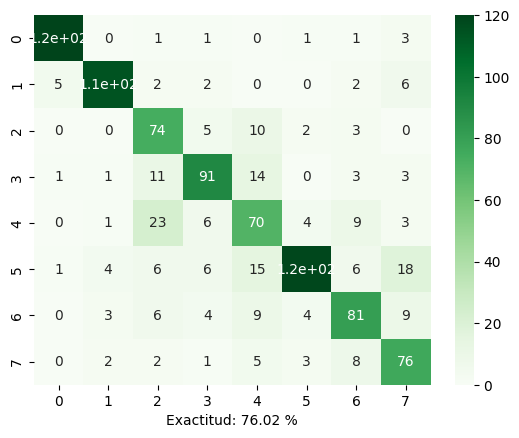

              precision    recall  f1-score   support

           0       0.94      0.94      0.94       127
           1       0.91      0.87      0.89       131
           3       0.59      0.79      0.68        94
           4       0.78      0.73      0.76       124
           6       0.57      0.60      0.59       116
           9       0.89      0.68      0.77       175
          10       0.72      0.70      0.71       116
          11       0.64      0.78      0.71        97

    accuracy                           0.76       980
   macro avg       0.76      0.76      0.76       980
weighted avg       0.78      0.76      0.76       980



In [36]:
sns.heatmap(confusion_matrix(y_pred_RanF_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RanF_pca, y_test))

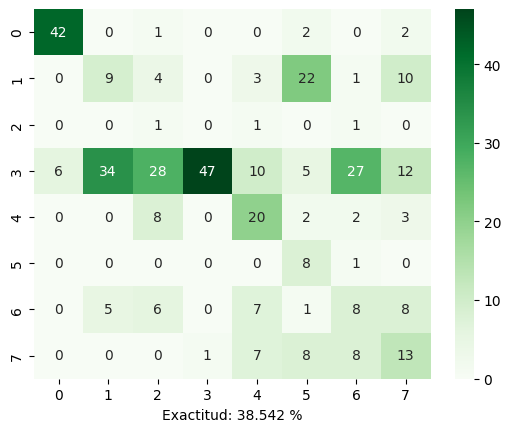

              precision    recall  f1-score   support

           0       0.88      0.89      0.88        47
           1       0.19      0.18      0.19        49
           3       0.02      0.33      0.04         3
           4       0.98      0.28      0.43       169
           6       0.42      0.57      0.48        35
           9       0.17      0.89      0.28         9
          10       0.17      0.23      0.19        35
          11       0.27      0.35      0.31        37

    accuracy                           0.39       384
   macro avg       0.39      0.47      0.35       384
weighted avg       0.65      0.39      0.42       384



In [37]:
sns.heatmap(confusion_matrix(y_pred_RanF_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RanF_pca_val, y_val))

Rotation forest

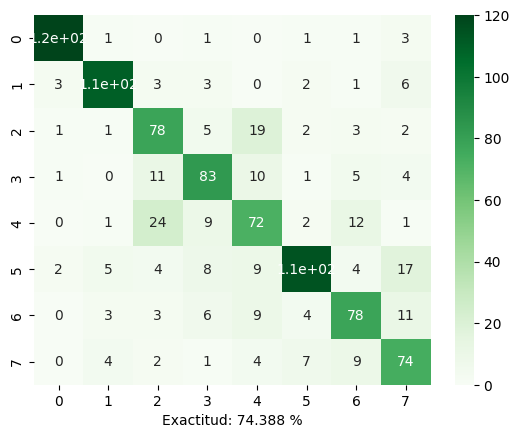

              precision    recall  f1-score   support

           0       0.94      0.94      0.94       127
           1       0.88      0.86      0.87       128
           3       0.62      0.70      0.66       111
           4       0.72      0.72      0.72       115
           6       0.59      0.60      0.59       121
           9       0.86      0.70      0.77       163
          10       0.69      0.68      0.69       114
          11       0.63      0.73      0.68       101

    accuracy                           0.74       980
   macro avg       0.74      0.74      0.74       980
weighted avg       0.75      0.74      0.75       980



In [38]:
sns.heatmap(confusion_matrix(y_pred_RotF_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RotF_pca, y_test))

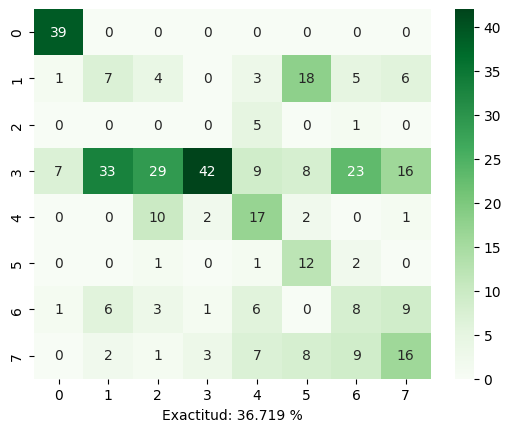

              precision    recall  f1-score   support

           0       0.81      1.00      0.90        39
           1       0.15      0.16      0.15        44
           3       0.00      0.00      0.00         6
           4       0.88      0.25      0.39       167
           6       0.35      0.53      0.42        32
           9       0.25      0.75      0.38        16
          10       0.17      0.24      0.20        34
          11       0.33      0.35      0.34        46

    accuracy                           0.37       384
   macro avg       0.37      0.41      0.35       384
weighted avg       0.57      0.37      0.39       384



In [39]:
sns.heatmap(confusion_matrix(y_pred_RotF_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RotF_pca_val, y_val))

Artificial Neural Networks (ANN)

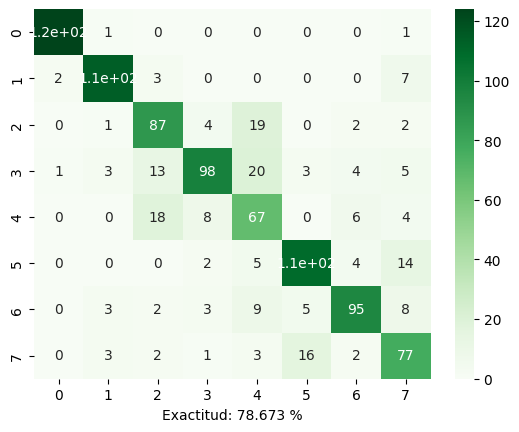

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       126
           1       0.91      0.90      0.91       126
           3       0.70      0.76      0.72       115
           4       0.84      0.67      0.75       147
           6       0.54      0.65      0.59       103
           9       0.82      0.81      0.82       134
          10       0.84      0.76      0.80       125
          11       0.65      0.74      0.69       104

    accuracy                           0.79       980
   macro avg       0.79      0.78      0.78       980
weighted avg       0.80      0.79      0.79       980



In [40]:
sns.heatmap(confusion_matrix(y_pred_ann_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_ann_pca, y_test))

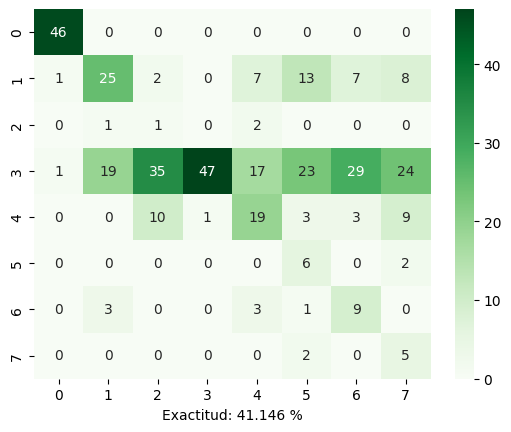

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        46
           1       0.52      0.40      0.45        63
           3       0.02      0.25      0.04         4
           4       0.98      0.24      0.39       195
           6       0.40      0.42      0.41        45
           9       0.12      0.75      0.21         8
          10       0.19      0.56      0.28        16
          11       0.10      0.71      0.18         7

    accuracy                           0.41       384
   macro avg       0.41      0.54      0.37       384
weighted avg       0.76      0.41      0.46       384



In [41]:
sns.heatmap(confusion_matrix(y_pred_ann_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_ann_pca_val, y_val))

Rpoerte de PCA

In [42]:
X

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,rms_2,iemg_2,mav_2,wl_2,...,fft_14,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus
0,-0.255698,-0.244309,-0.299656,-0.253076,-0.283206,-0.114716,-0.347830,-0.311202,-0.320954,-0.303129,...,-0.687847,1.130753,-1.055961,0.079656,-0.855036,-1.248659,0.517134,-0.203923,-0.212313,0.0
1,-0.196058,-0.212726,-0.177272,-0.184478,-0.202533,-0.112171,-0.332103,-0.313680,-0.307878,-0.303257,...,-1.050326,0.459962,-1.060829,0.268744,-1.049020,-1.664390,-0.031947,-0.110764,-0.500935,0.0
2,-0.469461,-0.603828,-0.538753,-0.721724,-0.565815,-0.139379,-0.370911,-0.382040,-0.369905,-0.462597,...,-1.410267,2.827498,-1.249001,0.457832,-1.436988,-1.617148,0.810732,-0.440777,-0.657365,0.0
3,-0.274513,-0.203073,-0.257919,-0.182450,-0.202171,-0.117037,-0.343882,-0.313355,-0.322492,-0.306010,...,-0.611517,0.967356,-1.228588,-0.109432,-0.790375,-1.305350,-0.427106,-0.318244,-0.088956,0.0
4,-0.338940,-0.405633,-0.388151,-0.477151,-0.403066,-0.126779,-0.344416,-0.333492,-0.329619,-0.349642,...,-0.804656,0.473387,-0.988306,-0.298520,-1.189119,-1.532112,-0.790030,-0.107929,-0.054782,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3259,-0.497135,-0.533508,-0.537021,-0.748151,-0.437738,-0.139181,1.193676,0.685122,0.674994,0.615065,...,0.756538,-0.012603,0.828210,0.646920,1.095578,0.555989,0.789542,-0.467921,-0.524209,0.0
3260,-0.459768,-0.414181,-0.464423,-0.685365,-0.364893,-0.135037,2.896829,2.808530,2.536761,3.021467,...,0.982907,0.019497,0.557654,0.268744,1.149462,1.094549,0.164688,-0.513502,-0.217399,0.0
3261,-0.586549,-0.621911,-0.614687,-0.913116,-0.550114,-0.145036,2.311794,1.572909,1.608373,1.642336,...,0.536510,-0.279795,0.609041,0.268744,0.707610,0.367021,1.122793,-0.491985,-0.215213,0.0
3262,-0.464297,-0.474073,-0.517722,-0.734965,-0.446241,-0.135509,1.489311,1.135897,1.012047,1.189468,...,1.026997,0.207738,0.710212,0.836008,1.197958,0.905581,1.309569,-0.388160,-0.392729,0.0
